<h1 align="center"> CODEX — SURVEY DATA CLEANING</h1>
<h3 align="center"> Preparing Clean & Reliable Data for Machine Learning</h3>

**Name:** Angadi Abhinay  
**Education:** B.Tech – Electronics and Communication Engineering (ECE)  
**Current Role:** Software R&D Engineer  
**Career Focus:** Data Science | Machine Learning | Artificial Intelligence

## 📋 Dataset Overview

### 🎯 About the Dataset

The dataset contains **survey responses from energy drink consumers**. It captures information about respondents' **demographics, occupation, income, consumption habits, brand preferences, purchasing behavior, and health concerns**.

The primary objective of this data-cleaning project is to identify and resolve data-quality issues so that the dataset is **accurate, consistent, and ready for the machine learning modeling stage**.

### 📊 Dataset Features

| Column | Description | Data Type |
|---|---|---|
| `respondent_id` | Unique identifier for each survey respondent | Categorical |
| `age` | Age of the respondent in years | Numerical |
| `gender` | Gender of the respondent | Categorical |
| `zone` | Geographic zone of the respondent | Categorical |
| `occupation` | Occupation of the respondent | Categorical |
| `income_levels` | Annual income level of the respondent | Categorical |
| `consume_frequency(weekly)` | Frequency of energy drink consumption per week | Categorical |
| `current_brand` | Current energy drink brand used by the respondent | Categorical |
| `preferable_consumption_size` | Preferred energy drink size | Categorical |
| `awareness_of_other_brands` | Number/range of other energy drink brands known | Categorical |
| `reasons_for_choosing_brands` | Primary reason for choosing an energy drink brand | Categorical |
| `flavor_preference` | Preferred energy drink flavor | Categorical |
| `purchase_channel` | Preferred channel for purchasing energy drinks | Categorical |
| `packaging_preference` | Preferred packaging type | Categorical |
| `health_concerns` | Level of health concern related to energy drinks | Categorical |
| `typical_consumption_situations` | Situations in which energy drinks are typically consumed | Categorical |
| `price_range` | Price range of energy drinks typically purchased | Categorical **(Target)** |

### 🔍 Data Quality Focus

The cleaning process will primarily focus on:

- 🔄 Identifying and removing **duplicate records**
- 📈 Detecting and handling **age outliers**
- ❌ Identifying and treating **missing values**
- ✏️ Correcting **spelling and formatting inconsistencies**
- 🏷️ Standardizing **categorical values**
- 🎯 Ensuring the dataset is suitable for **machine learning modeling**

### 🎯 Target Variable

The target variable for the modeling stage is:

**`price_range`**

It represents the **price range of energy drinks typically purchased by the respondent**.

### 💡 Project Objective

The goal of this data-cleaning stage is to transform the raw survey data into a **clean, consistent, and reliable dataset** that can be confidently used for further **exploratory data analysis and machine learning modeling**.

## 🔄 Step 1: Remove Duplicate Records

The first step is to investigate whether the dataset contains **duplicate survey responses**.

Duplicate records can cause certain respondents or patterns to be counted more than once. This may lead to **biased analysis and affect the performance of the machine learning model**.

### 🔍 Identifying Duplicates

The `respondent_id` column is described as a **unique identifier for each respondent**, so it should normally contain a unique value for every survey response.

We will check:

1. Whether any `respondent_id` values are duplicated.
2. Whether the entire survey response is duplicated across all columns.

If duplicate records are found, they will be removed while keeping the first occurrence.

### 💡 Why Remove Duplicates?

Removing duplicate records helps ensure that:

- Each respondent is represented appropriately.
- Customer behavior is not over-counted.
- Statistical analysis is more reliable.
- The machine learning model is not biased toward repeated observations.

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [140]:
df = pd.read_csv('survey_results.csv')
df.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


In [141]:
df.shape

(30010, 17)

In [142]:
df['respondent_id'].duplicated().sum()

10

In [143]:
df[df.duplicated(keep=False)]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
2308,R02309,27,M,Urban,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200
2309,R02309,27,M,Urban,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Brand Reputation,Traditional,Online,Simple,Medium (Moderately health-conscious),Social (eg. Parties),150-200
2665,R02665,61,M,Metro,Entrepreneur,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
2666,R02665,61,M,Metro,Entrepreneur,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Retail Store,Simple,High (Very health-conscious),"Active (eg. Sports, gym)",200-250
5150,R05149,21,M,Semi-Urban,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
5151,R05149,21,M,Semi-Urban,Student,NaN,3-4 times,Established,Small (250 ml),2 to 4,Availability,Traditional,Retail Store,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
7793,R07791,25,M,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
7794,R07791,25,M,Metro,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
8515,R08512,20,F,Metro,Student,NaN,5-7 times,Established,Large (1 L),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
8516,R08512,20,F,Metro,Student,NaN,5-7 times,Established,Large (1 L),0 to 1,Price,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150


In [144]:
# Remove duplicate records based on respondent_id
df = df.drop_duplicates(subset='respondent_id').copy()


In [145]:
df.duplicated().sum()

0

In [146]:
df.shape

(30000, 17)

## 📊 Step 2: Outlier Detection in Age

The `age` column contains the age of each survey respondent. Before using the data for analysis and machine learning, we need to check whether it contains any **unusually high or low values**.

Extreme age values can affect statistical analysis and may influence the performance of a machine learning model.

### 🔍 Method Used: Interquartile Range (IQR)

We will use the **Interquartile Range (IQR) method** to identify potential outliers.

First, we calculate:

- **Q1 (25th percentile)** → Lower quartile
- **Q3 (75th percentile)** → Upper quartile
- **IQR** → Difference between Q3 and Q1

The lower and upper boundaries are calculated as:

$$
IQR = Q3 - Q1
$$

$$
Lower\ Bound = Q1 - 1.5 \times IQR
$$

$$
Upper\ Bound = Q3 + 1.5 \times IQR
$$

Any age value below the lower bound or above the upper bound will be considered a **potential outlier**.

### 📦 Visual Inspection

A box plot will also be used to visually inspect the distribution of ages and identify potential outliers.

### 💡 Why Is This Important?

Outliers may:

- Distort statistical summaries such as the mean.
- Affect patterns identified during exploratory analysis.
- Influence machine learning model training.
- Indicate data-entry or survey errors.

However, an outlier is **not automatically an incorrect value**. A valid respondent with an unusual age should not be removed without investigation.

### 🧹 Handling Decision

After identifying the potential outliers, we will inspect them and determine whether they are:

- **Valid observations** → Keep them.
- **Data-entry or invalid values** → Correct or remove them where appropriate.

We should avoid removing valid respondents simply because their age falls outside the typical range.

In [147]:
#1. First, inspect the age column

# Basic statistics of age
df['age'].describe()

count    30000.000000
mean        33.048167
std         13.438904
min         18.000000
25%         23.000000
50%         31.000000
75%         40.000000
max        604.000000
Name: age, dtype: float64

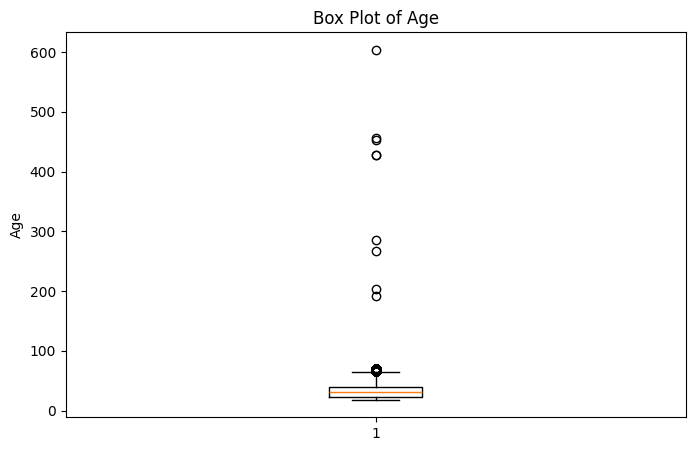

In [148]:
#2. Visualize the age distribution

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df['age'].dropna())
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

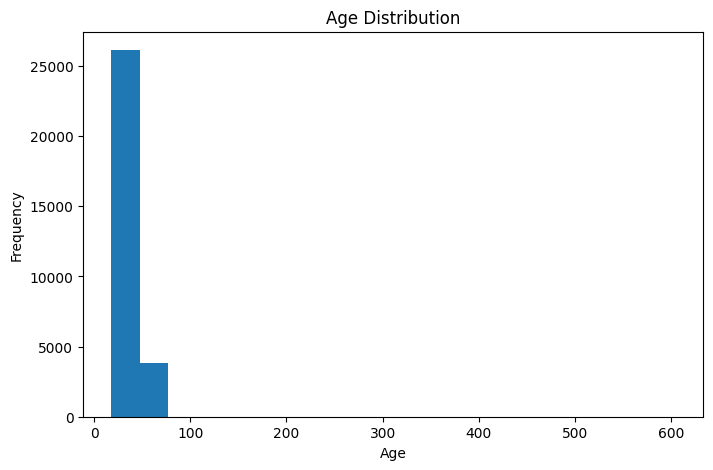

In [149]:
plt.figure(figsize=(8, 5))
plt.hist(df['age'].dropna(), bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [150]:
#3. Detect outliers using IQR

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 23.0
Q3: 40.0
IQR: 17.0


In [151]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -2.5
Upper Bound: 65.5


In [152]:
#4. Find the actual outlier records

age_outliers = df[
    (df['age'] < lower_bound) |
    (df['age'] > upper_bound)
]

age_outliers.shape

(493, 17)

In [153]:
age_outliers['age'].value_counts().sort_index()

age
66      99
67     106
68      87
69      98
70      94
192      1
203      1
267      1
285      1
428      2
453      1
457      1
604      1
Name: count, dtype: int64

In [154]:
# 6. Check for impossible ages

df[(df['age'] < 0) | (df['age'] > 100)]

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
3099,R03098,453,M,Metro,Working Professional,26L - 35L,3-4 times,Established,Medium (500 ml),2 to 4,Brand Reputation,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
6262,R06260,428,M,Urban,Entrepreneur,16L - 25L,5-7 times,Established,Large (1 L),above 4,Quality,Exotic,Online,Simple,High (Very health-conscious),Social (eg. Parties),200-250
12403,R12398,604,M,Metro,Retired,<10L,0-2 times,Newcomer,Small (250 ml),2 to 4,Availability,Traditional,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),100-150
22549,R22542,457,M,Metro,Working Professional,16L - 25L,3-4 times,Newcomer,Small (250 ml),2 to 4,Price,Traditional,Online,Premium,High (Very health-conscious),Casual (eg. At home),200-250
22918,R22911,267,F,Metro,Working Professional,16L - 25L,3-4 times,Established,Medium (500 ml),above 4,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
24958,R24950,285,M,Semi-Urban,Working Professional,> 35L,0-2 times,Newcomer,Small (250 ml),2 to 4,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",150-200
24960,R24952,192,F,Urban,Student,NaN,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Low (Not very concerned),"Active (eg. Sports, gym)",50-100
25105,R25096,203,M,Metro,Working Professional,16L - 25L,0-2 times,Established,Small (250 ml),2 to 4,Brand Reputation,Exotic,Retail Store,Premium,High (Very health-conscious),"Active (eg. Sports, gym)",150-200
28770,R28761,428,F,Rural,Working Professional,26L - 35L,0-2 times,Established,Small (250 ml),2 to 4,Brand Reputation,Exotic,Online,Simple,Medium (Moderately health-conscious),Casual (eg. At home),150-200


In [155]:
# Remove biologically impossible ages (> 100)
df = df[df['age'] <= 100].copy()

# Verify that no age above 100 remains
print('Rows with age > 100:', (df['age'] > 100).sum())


Rows with age > 100: 0


### 🧹 Age Outlier Handling

The `age` column was analyzed using **descriptive statistics, a box plot, and the IQR method** to identify potential outliers.

The identified values were further checked for validity. Statistical outliers were **retained when they represented realistic ages**, as removing valid respondents could result in unnecessary loss of information.

Only **clearly invalid age values** should be corrected or removed.

### ✅ Final Decision

The presence of a statistical outlier does not necessarily mean that the observation is incorrect. Therefore, valid age values were **retained**, while only values that are clearly invalid or the result of data-entry errors should be removed or corrected.

This approach helps preserve the original survey information while preventing genuinely incorrect data from affecting the modeling process.

### Step 3: Handling Missing Data

Missing values can affect data analysis and may cause problems during the machine learning modeling stage.

In this step, we will identify missing values and determine an appropriate strategy for handling them in the categorical columns.

The main columns considered are:

- `income_levels`
- `purchase_channel`

In [156]:
#1. Check missing values

print("Missing values:")
print(df[['income_levels', 'purchase_channel']].isnull().sum())

Missing values:
income_levels       8060
purchase_channel      10
dtype: int64


In [157]:
# 2. Handle income_levels

print(df['income_levels'].value_counts(dropna=False))

income_levels
NaN          8060
16L - 25L    5897
10L - 15L    5251
<10L         4661
26L - 35L    3872
> 35L        2250
Name: count, dtype: int64


In [158]:
df['income_levels'] = df['income_levels'].fillna('Not Reported')

In [159]:
print(df['income_levels'].isnull().sum())

0


In [160]:
print(df['income_levels'].value_counts())

income_levels
Not Reported    8060
16L - 25L       5897
10L - 15L       5251
<10L            4661
26L - 35L       3872
> 35L           2250
Name: count, dtype: int64


In [161]:
# 3. Handle purchase_channel

print(df['purchase_channel'].value_counts(dropna=False))

purchase_channel
Online          16562
Retail Store    13419
NaN                10
Name: count, dtype: int64


In [162]:
purchase_channel_mode = df['purchase_channel'].mode()[0]

print("Most common purchase channel:", purchase_channel_mode)

Most common purchase channel: Online


In [163]:
df['purchase_channel'] = df['purchase_channel'].fillna(
    purchase_channel_mode
)

In [164]:
print(df['purchase_channel'].isnull().sum())

0


In [165]:
# 5. Check all missing values after cleaning
df[['income_levels', 'purchase_channel']].isnull().sum()

income_levels       0
purchase_channel    0
dtype: int64

In [166]:
# Count null values
null_values_count = df['consume_frequency(weekly)'].isnull().sum()

# Find mode
mode_value = df['consume_frequency(weekly)'].mode()[0]

print('Null values:', null_values_count)
print('Mode value:', mode_value)

# Fill missing values with the mode
df['consume_frequency(weekly)'] = df['consume_frequency(weekly)'].fillna(mode_value)
print('Remaining null values:', df['consume_frequency(weekly)'].isnull().sum())


Null values: 8
Mode value: 3-4 times
Remaining null values: 0


In [167]:
# Count null values
null_values_count = df['consume_frequency(weekly)'].isnull().sum()

# Find mode
mode_value = df['consume_frequency(weekly)'].mode()[0]

print(null_values_count, mode_value)

0 3-4 times


## ✏️ Step 4: Correcting Spelling Mistakes in Categorical Data
Categorical columns can contain inconsistencies such as:

- Spelling mistakes
- Extra spaces
- Different capitalization
- Different formatting for the same category

Such inconsistencies can create duplicate categories and affect data analysis and machine learning models.

In this step, we will review the following columns:

- `zone`
- `current_brand`

### 🔍 Step 1: Inspect Unique Categories

We will first identify all unique values in both columns.

This allows us to detect categories that may represent the same value but are written differently.

### 🧹 Step 2: Standardize Formatting

We will check for:

- Leading or trailing spaces
- Inconsistent capitalization
- Spelling variations
- Duplicate categories caused by formatting differences

For example, values such as:

`Urban`, `urban`, and ` Urban `

should be standardized to a single category:

`Urban`

### 🔧 Step 3: Correct Spelling Inconsistencies

If spelling variations are identified, they will be mapped to the correct standardized category.

The corrections will be based on the actual categories present in the dataset rather than making assumptions about new categories.

### ✅ Final Objective

After cleaning, each category should have a **single consistent representation**.

This ensures that:

- Category counts are accurate.
- Exploratory analysis is reliable.
- Encoding creates the correct number of categories.
- The machine learning model receives consistent categorical features.

In [168]:
# 1. Check unique values in zone

print("Unique values in zone:")
print(df['zone'].unique())

Unique values in zone:
['Urban' 'Metro' 'Rural' 'Semi-Urban' 'Metor' 'urbna']


In [169]:
print(df['zone'].value_counts(dropna=False))

zone
Metro         11906
Urban         10686
Semi-Urban     5274
Rural          2116
urbna             5
Metor             4
Name: count, dtype: int64


In [170]:
# 2. Check unique values in current_brand

print("Unique values in current_brand:")
print(df['current_brand'].unique())

Unique values in current_brand:
['Newcomer' 'Established' 'newcomer' 'Establishd']


In [171]:
print(df['current_brand'].value_counts(dropna=False))

current_brand
Established    15442
Newcomer       14499
newcomer          30
Establishd        20
Name: count, dtype: int64


In [172]:
# 3. Remove unnecessary spaces

print(df['zone'].astype(str).str.strip().unique())

['Urban' 'Metro' 'Rural' 'Semi-Urban' 'Metor' 'urbna']


In [173]:
print(df['current_brand'].astype(str).str.strip().unique())

['Newcomer' 'Established' 'newcomer' 'Establishd']


In [174]:
df['zone'] = df['zone'].str.strip()
df['current_brand'] = df['current_brand'].str.strip()

In [175]:
# 4. Standardize capitalization

df['zone'] = df['zone'].str.strip().str.title()

In [176]:
df['current_brand'] = df['current_brand'].str.strip().str.title()

In [177]:
# 5. Identify spelling mistakes

df['zone'] = df['zone'].replace({
    'Semi Urban': 'Semi-Urban'
})

In [178]:
df['current_brand'] = df['current_brand'].replace({
    'Establised': 'Established'
})

In [179]:
# 6. Better approach: inspect before and after

# Check unique values before cleaning
print("Zone values before cleaning:")
print(df['zone'].value_counts(dropna=False))

print("\nCurrent Brand values before cleaning:")
print(df['current_brand'].value_counts(dropna=False))

Zone values before cleaning:
zone
Metro         11906
Urban         10686
Semi-Urban     5274
Rural          2116
Urbna             5
Metor             4
Name: count, dtype: int64

Current Brand values before cleaning:
current_brand
Established    15442
Newcomer       14529
Establishd        20
Name: count, dtype: int64


In [180]:
# Remove leading and trailing spaces
df['zone'] = df['zone'].str.strip()
df['current_brand'] = df['current_brand'].str.strip()

In [181]:
print("Zone values after removing spaces:")
print(df['zone'].value_counts(dropna=False))

print("\nCurrent Brand values after removing spaces:")
print(df['current_brand'].value_counts(dropna=False))

Zone values after removing spaces:
zone
Metro         11906
Urban         10686
Semi-Urban     5274
Rural          2116
Urbna             5
Metor             4
Name: count, dtype: int64

Current Brand values after removing spaces:
current_brand
Established    15442
Newcomer       14529
Establishd        20
Name: count, dtype: int64


In [182]:
print("\nUnique Zone values:")
print(df['zone'].unique())

print("\nUnique Current Brand values:")
print(df['current_brand'].unique())


Unique Zone values:
['Urban' 'Metro' 'Rural' 'Semi-Urban' 'Metor' 'Urbna']

Unique Current Brand values:
['Newcomer' 'Established' 'Establishd']


In [183]:
# 7. Verify the final categories

print("Final Zone categories:")
print(df['zone'].value_counts())

print("\nFinal Current Brand categories:")
print(df['current_brand'].value_counts())

Final Zone categories:
zone
Metro         11906
Urban         10686
Semi-Urban     5274
Rural          2116
Urbna             5
Metor             4
Name: count, dtype: int64

Final Current Brand categories:
current_brand
Established    15442
Newcomer       14529
Establishd        20
Name: count, dtype: int64


In [184]:
df['zone'].value_counts(dropna=False)

zone
Metro         11906
Urban         10686
Semi-Urban     5274
Rural          2116
Urbna             5
Metor             4
Name: count, dtype: int64

In [185]:
# Show all unique zone values
print(df['zone'].unique())

['Urban' 'Metro' 'Rural' 'Semi-Urban' 'Metor' 'Urbna']


In [186]:
count = (df['zone'] == 'Metor').sum()
print(count)

4


In [187]:
df.shape

(29991, 17)

<h3 align="center"> Data Preprocessing and Feature Engineering</h3>

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Step 1: Categorize Age into Age Groups

### 🎯 Objective

The `age` column contains individual ages. To make the data easier to analyze and suitable for categorical modeling, we will convert the numerical `age` column into meaningful age groups.

The following age groups will be created:

| Age Range | Age Group |
|---|---|
| 18–25 | `18-25` |
| 26–35 | `26-35` |
| 36–45 | `36-45` |
| 46–55 | `46-55` |
| 56–70 | `56-70` |
| Above 70 | `70+` |

A new column named `age_group` will be created.

### 🔍 Age Group Mapping

Each respondent will be assigned to exactly one age group based on their `age`.

After creating `age_group`, the original `age` column will be removed because the grouped representation will be used for further analysis and modeling.

### ✅ Validation

After categorization, we will verify that:

- `age_group` contains only the expected categories.
- No valid age is left uncategorized.
- The original `age` column has been removed.

In [189]:
# Continue feature engineering using the cleaned dataset from the data-cleaning steps above.
# Do not reload the raw CSV here, because that would reintroduce duplicates and
# undo the categorical cleaning already performed in `df`.
df1 = df.copy()
df1.head(3)


,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250


For Step 1 of Feature Engineering, use pd.cut() to convert the numerical age column into the required categorical age_group.

In [190]:
# Create age groups

bins = [17, 25, 35, 45, 55, 70, float('inf')]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70', '70+']

In [191]:
df1['age_group'] = pd.cut(df1['age'],bins=bins,labels=labels)
df1.head(3)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45


In [192]:
df1['age_group'].isnull().sum()

0

## 📊 Step 2: Create `cf_ab_score`

### 🎯 Objective

The objective is to create a new numerical feature called `cf_ab_score` by combining:

- `consume_frequency(weekly)`
- `awareness_of_other_brands`

Both categorical variables will first be converted into numerical scores.

### 🔢 Consume Frequency Mapping

| `consume_frequency(weekly)` | Score |
|---|---:|
| `0-2 times` | 1 |
| `3-4 times` | 2 |
| `5-7 times` | 3 |

### 🔢 Brand Awareness Mapping

| `awareness_of_other_brands` | Score |
|---|---:|
| `0 to1` | 1 |
| `2 to4` | 2 |
| `above 4` | 3 |

### 🧮 Score Calculation

After converting both categorical variables into numerical scores, the `cf_ab_score` is calculated using:

$$
cf\_ab\_score =
\frac{frequency\_score}{awareness\_score+frequency\_score}
$$

The resulting score is rounded to **two decimal places**.

### 🎯 Interpretation

The score combines the respondent's **consumption frequency** and **awareness of other brands** into a single numerical feature.

A higher `cf_ab_score` indicates relatively higher consumption frequency and/or greater awareness of other brands.

In [193]:
# Mapping for consume frequency
cf_mapping = {
    '0-2 times': 1,
    '3-4 times': 2,
    '5-7 times': 3
}

# Mapping for awareness of other brands
ab_mapping = {
    '0 to 1': 1,
    '2 to 4': 2,
    'above 4': 3
}

In [194]:
# 2. Convert the two columns to numerical scores

df1['cf_score'] = df1['consume_frequency(weekly)'].map(cf_mapping)

df1['ab_score'] = df1['awareness_of_other_brands'].map(ab_mapping)

In [195]:
df1.head(3)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range,age_group,cf_score,ab_score
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150,26-35,2,1
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250,46-55,3,2
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250,36-45,2,2


In [196]:
# Step 3: Calculate cf_ab_score

df1['cf_ab_score'] = (
    df1['cf_score'] /
    (df1['cf_score'] + df1['ab_score'])
).round(2)

In [197]:
df1['cf_ab_score'].head(3)

0    0.67
1    0.60
2    0.50
Name: cf_ab_score, dtype: float64

In [198]:
# Step 4: Check the result

df1[['consume_frequency(weekly)','awareness_of_other_brands','cf_score','ab_score','cf_ab_score']].head(10)

,consume_frequency(weekly),awareness_of_other_brands,cf_score,ab_score,cf_ab_score
0,3-4 times,0 to 1,2,1,0.67
1,5-7 times,2 to 4,3,2,0.60
2,3-4 times,2 to 4,2,2,0.50
3,5-7 times,0 to 1,3,1,0.75
4,3-4 times,0 to 1,2,1,0.67
5,5-7 times,2 to 4,3,2,0.60
6,5-7 times,2 to 4,3,2,0.60
7,5-7 times,above 4,3,3,0.50
8,5-7 times,2 to 4,3,2,0.60
9,5-7 times,2 to 4,3,2,0.60


In [199]:
df1['cf_ab_score'].max()

0.75

## 🏙️ Step 3: Create Zone Affluence Score (ZAS)

### 🎯 Objective

The objective is to create a new numerical feature called `zas_score` by combining information from:

- `zone`
- `income_levels`

Both categorical variables will first be converted into numerical scores.

### 🗺️ Zone Score Mapping

| Zone | Score |
|---|---:|
| `Rural` | 1 |
| `Semi-Urban` | 2 |
| `Urban` | 3 |
| `Metro` | 4 |

### 💰 Income Score Mapping

| Income Level | Score |
|---|---:|
| `<10L` | 1 |
| `10L- 15L` | 2 |
| `16L- 25L` | 3 |
| `26L- 35L` | 4 |
| `>35L` | 5 |
| `Not Reported` | 0 |

### 🧮 ZAS Calculation

The `zas_score` is calculated by taking the average of the zone score and income score:

$$
zas\_score =
\frac{zone\_score * income\_score}
$$

The result will be rounded to two decimal places.

### 🎯 Interpretation

The `zas_score` combines **geographical affluence** and **income level** into a single numerical feature.

A higher score generally represents a combination of a more affluent zone and a higher reported income level.

In [200]:
df1['zone'].unique()

array(['Urban', 'Metro', 'Rural', 'Semi-Urban', 'Metor', 'Urbna'],
      dtype=object)

In [201]:
df1['income_levels'].unique()

array(['<10L', '> 35L', '16L - 25L', 'Not Reported', '10L - 15L',
       '26L - 35L'], dtype=object)

In [202]:
df1['income_levels'].isna().sum()

0

In [203]:
df1['income_levels'] = df1['income_levels'].fillna('Not Reported')

In [204]:
df1['income_levels'] = df1['income_levels'].replace({
    '> 35L': '>35L',
    '16L - 25L': '16L- 25L',
    '10L - 15L': '10L- 15L',
    '26L - 35L': '26L- 35L'
})

In [205]:
df1['zone'] = df1['zone'].replace({
    'Metor': 'Metro',
    'urbna': 'Urban'
})

In [206]:
# 1. Create the mappings
zone_mapping = {
    'Urban': 3,
    'Metro': 4,
    'Rural': 1,
    'Semi-Urban': 2
}

income_mapping = {
    '<10L': 1,
    '10L- 15L': 2,
    '16L- 25L': 3,
    '26L- 35L': 4,
    '>35L': 5,
    'Not Reported': 0
}

In [207]:
# 2. Map the columns

df1['zone_score'] = df1['zone'].map(zone_mapping)

df1['income_score'] = df1['income_levels'].map(income_mapping)

In [208]:
# 3. Check if anything failed to map
print("Unmapped zone values:")
print(df1.loc[df1['zone_score'].isna(), 'zone'].unique())

print("\nUnmapped income values:")
print(df1.loc[df1['income_score'].isna(), 'income_levels'].unique())

Unmapped zone values:
['Urbna']

Unmapped income values:
[]


In [209]:
# 4. Calculate zas_score

df1['zas_score'] = (
    df1['zone_score'] * df1['income_score']
)

In [210]:
# 5. Check the result

df1[['zone','income_levels','zone_score','income_score','zas_score']].head(10)

,zone,income_levels,zone_score,income_score,zas_score
0,Urban,<10L,3.0,1,3.0
1,Metro,>35L,4.0,5,20.0
2,Rural,>35L,1.0,5,5.0
3,Urban,16L- 25L,3.0,3,9.0
4,Metro,Not Reported,4.0,0,0.0
5,Urban,Not Reported,3.0,0,0.0
6,Urban,10L- 15L,3.0,2,6.0
7,Urban,26L- 35L,3.0,4,12.0
8,Semi-Urban,<10L,2.0,1,2.0
9,Semi-Urban,10L- 15L,2.0,2,4.0


In [211]:
print(len(df1['zas_score'].unique()))

15


## 🔄 Step 4: Brand Switching Indicator (BSI)

### 🎯 Objective

The objective is to create a binary indicator called `bsi` to identify respondents who may have a higher potential for switching from their current brand.

A respondent will be assigned:

- **`1`** → Potential brand switcher
- **`0`** → Not identified as a potential brand switcher

### 🔍 Conditions

A respondent will receive a `bsi` value of **1** only when both conditions are satisfied:

1. `current_brand` is **not** `"Established"`.
2. `reasons_for_choosing_brands` is either **`"Price"`** or **`"Quality"`**.

If either condition is false, the respondent will receive a value of **0**.


This creates a binary feature that can be used during further analysis and machine learning.

In [212]:
df1['bsi'] = (
    (df1['current_brand'] != 'Established') &
    (df1['reasons_for_choosing_brands'].isin(['Price', 'Quality']))
).astype(int)

In [213]:
df1['bsi'].value_counts()

bsi
0    20804
1     9187
Name: count, dtype: int64

In [214]:
df1.shape

(29991, 25)

In [215]:
print(len(df1[df1['bsi'] == 0]))

20804


## 🧹 Final Cleaning Step: Removing Logical Outliers

### 🎯 Objective

After the earlier cleaning steps, the analysis continues from the cleaned `df` dataset. We check for logical inconsistencies between `age_group` and `occupation`.

For this dataset, the specific logical inconsistency is:
- `age_group = 56-70`
- `occupation = Student`

These records are removed because the combination is considered logically inconsistent for this analysis.

### 🔍 Identification and Removal

The number of matching records is counted before removal. Only those records are removed, and the remaining dataset is validated to ensure none are left.

### ⚠️ Important

The feature-engineering section uses `df.copy()` rather than re-reading `survey_results.csv`. This ensures duplicate removal and categorical cleaning performed earlier are retained throughout the analysis.


In [216]:
bins = [17, 25, 35, 45, 55, 70, float('inf')]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70', '70+']

df1['age_group'] = pd.cut(
    df1['age'],
    bins=bins,
    labels=labels
)

In [217]:
df1.shape

(29991, 25)

In [218]:
pd.crosstab(df1['age_group'], df1['occupation'])

occupation,Entrepreneur,Retired,Student,Working Professional
age_group,,,,
18-25,535,0,7328,2605
26-35,1826,0,697,6570
36-45,1619,0,0,4353
46-55,799,0,0,2167
56-70,221,1130,35,106


In [219]:
df1[
    (df1['age_group'] == '56-70') &
    (df1['occupation'] == 'Student')
].head(3)

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,...,typical_consumption_situations,price_range,age_group,cf_score,ab_score,cf_ab_score,zone_score,income_score,zas_score,bsi
182,R00183,65,F,Urban,Student,Not Reported,5-7 times,Established,Large (1 L),above 4,...,Casual (eg. At home),150-200,56-70,3,3,0.50,3.0,0,0.0,0
3526,R03525,59,F,Semi-Urban,Student,Not Reported,0-2 times,Established,Medium (500 ml),0 to 1,...,"Active (eg. Sports, gym)",50-100,56-70,1,1,0.50,2.0,0,0.0,0
3527,R03526,61,M,Semi-Urban,Student,Not Reported,0-2 times,Newcomer,Small (250 ml),2 to 4,...,Casual (eg. At home),100-150,56-70,1,2,0.33,2.0,0,0.0,1


In [220]:
# Count logical outliers before removal
logical_outlier_mask = (
    (df1['age_group'] == '56-70') &
    (df1['occupation'] == 'Student')
)

logical_outlier_count = logical_outlier_mask.sum()
print('Logical outliers before removal:', logical_outlier_count)

# Remove only the identified logical outliers
df1 = df1.loc[~logical_outlier_mask].copy()

print('Rows after logical-outlier removal:', len(df1))


Logical outliers before removal: 35
Rows after logical-outlier removal: 29956


In [221]:
# Final validation: no 56-70 Students should remain
remaining_logical_outliers = (
    (df1['age_group'] == '56-70') &
    (df1['occupation'] == 'Student')
).sum()

print('Remaining logical outliers:', remaining_logical_outliers)


Remaining logical outliers: 0


In [222]:
# Remove the original age column after age_group has been created and used
df1 = df1.drop(columns=['age'])


In [223]:
df1['bsi'] = (
    (df1['current_brand'] != 'Established') &
    (df1['reasons_for_choosing_brands'].isin(['Price', 'Quality']))
).astype(int)

In [224]:
print('BSI = 0:', (df1['bsi'] == 0).sum())
print('BSI = 1:', (df1['bsi'] == 1).sum())
print('Total rows:', len(df1))


BSI = 0: 20784
BSI = 1: 9172
Total rows: 29956


<h3 align="center"> Predictive Modeling </h3>

In [ ]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ============================================================
# STEP 1: Prepare Features and Target Variables
# (Assumes `df` already has the cleaned + feature-engineered
# columns from your earlier data-cleaning / feature-engineering steps:
# age_group, cf_ab_score, zas_score, bsi, plus the original columns
# minus 'age'.)
# ============================================================
X = df.drop(columns=['respondent_id', 'price_range'])
y = df['price_range']

# ============================================================
# STEP 3 (encoding is set up before the split so train/test share
# the same column structure — see note above on why this is safe)
# ============================================================
label_encode_cols = [
    'age_group',
    'income_levels',
    'health_concerns',
    'consume_frequency(weekly)',
    'preferable_consumption_size'
]

for col in label_encode_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# All remaining text/categorical columns get One-Hot Encoding
onehot_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("One-hot encoding these columns:", onehot_cols)

X = pd.get_dummies(X, columns=onehot_cols, drop_first=True)

# Target variable: label encode
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)
print("Target classes (in encoded order):", list(target_encoder.classes_))

# ============================================================
# STEP 2: Data Splitting (75% train / 25% test, random_state=42)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Scaled versions — fit ONLY on training data, applied to both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# STEP 4 & 5: Model Selection + Performance Evaluation
# ============================================================
# Models that need scaled input (distance/coefficient-based)
scale_sensitive_models = {
    'Gaussian Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(random_state=42)
}

# Tree-based models — no scaling needed
tree_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

results = {}

print("\n" + "="*60)
print("SCALE-SENSITIVE MODELS (trained on scaled features)")
print("="*60)
for name, model in scale_sensitive_models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n--- {name} (took {time.time()-t0:.1f}s) ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=target_encoder.classes_))

print("\n" + "="*60)
print("TREE-BASED MODELS (trained on raw encoded features)")
print("="*60)
for name, model in tree_models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n--- {name} (took {time.time()-t0:.1f}s) ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=target_encoder.classes_))

# ============================================================
# STEP 6: Model Comparison
# ============================================================
comparison_df = pd.Series(results).sort_values(ascending=False).to_frame('Accuracy')
print("\n" + "="*60)
print("MODEL COMPARISON (sorted by accuracy)")
print("="*60)
print(comparison_df)

best_model_name = comparison_df.index[0]
print(f"\nBest performing model: {best_model_name} (Accuracy: {comparison_df.iloc[0,0]:.4f})")